In [103]:
from random_measurement import generate_povm_set_case_1,generate_povm_set_case_2,is_a_proper_povm
from blended_measurement import blended_measurement
from qiskit.extensions import *
from qiskit.circuit.add_control import add_control
from qiskit.visualization import plot_histogram
from qiskit import  BasicAer,transpile, QuantumRegister, ClassicalRegister, QuantumCircuit, execute, BasicAer
import numpy as np
import matplotlib.pyplot as plt
import sys
print(sys.executable)


/bin/python3


[0.01377291 0.01439814]
[0.00340255 0.0123272 ]
[0.00470088 0.00961044]
[0.00063303 0.01751242]
[0.01282072 0.01320938]
[0.00181798 0.00796108]
[0.01215379 0.01653157]
[0.00071309 0.01420582]
[0.00102303 0.0196725 ]
[0.01185345 0.01918003]
[0.0050522  0.01410423]
[0.00080552 0.00912147]
[0.00787622 0.00891019]
[0.00663388 0.00710604]
[0.00723071 0.00961465]
[0.00266118 0.01604911]
[0.00827123 0.01230418]
[0.0196954  0.01979599]
[0.00335301 0.00772111]
[0.00040138 0.00852072]
[0.00293844 0.00889253]
[1.99792102e-05 9.33667827e-03]
[0.01385556 0.01482344]
[0.01717753 0.01969497]
[0.01129019 0.01307424]
[0.00964463 0.01457915]
[0.00772632 0.01609864]
[0.00465325 0.00775861]
[0.00275964 0.00500513]
[0.00049584 0.00433298]
[0.00451091 0.0086158 ]
[0.0065628  0.01698998]
[0.00715831 0.01080029]
[0.00904725 0.0155811 ]
[0.00731516 0.01132043]
[0.01614698 0.0181455 ]
[0.01346574 0.01412344]
[0.00246077 0.01915737]
[0.00498443 0.00897669]
[0.00444902 0.0091937 ]
[0.01356098 0.01780437]
[0.00668

/home/jason/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jason/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


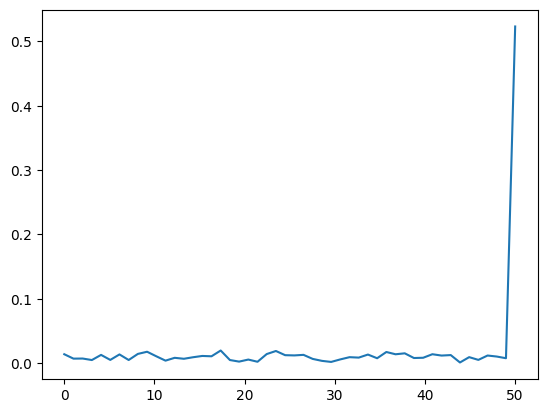

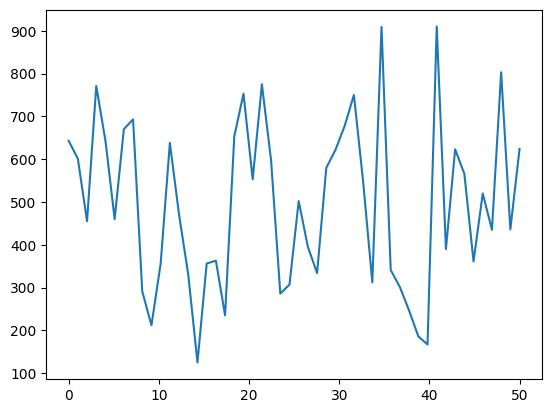

In [104]:

d = 2  # Dimension
m = 50 # Number of POVM elements
pro=[]
pro_x_axis=np.linspace(0, m)  
################### generate the povm measurement sets ##################################

povm_set_case_1 = generate_povm_set_case_1(d, m)
povm_set_case_2 = generate_povm_set_case_2(d, m)

################### show the povm set #################################################
povm_set_case=povm_set_case_1
for item in povm_set_case:
    eigenval,_=np.linalg.eigh(item)
    print(eigenval)
roh_0=np.array([[1,0],[0,0]])
for item in povm_set_case:
    pro.append(np.trace(item@roh_0))
    print(np.trace(item@roh_0))
# Verify the completeness relation
completeness_check = sum(povm_set_case)
print(is_a_proper_povm(povm_set_case))
print("Completeness check (should be close to the identity matrix):\n", completeness_check)

################## generate blended measurement sets #############################################

blended_case_1=blended_measurement(povm_set_case_1,d,m)
blended_case_2=blended_measurement(povm_set_case_2,d,m)

################# construct the quantum circuit #################################################
accepted_0=[]
x_axis=np.linspace(0,m)  
for i in range(m):
    eigenval,eigenvec=np.linalg.eigh(povm_set_case[i])
    qc = QuantumCircuit(1, 1)
    unitary_gate = UnitaryGate(eigenvec)

    #Apply the unitary gate to the qubit
    qc.append(unitary_gate, [0])
    # Measure the qubit in the computational basis
    qc.measure(0, 0)

    # Execute the circuit
    backend = BasicAer.get_backend('qasm_simulator')
    result = execute(qc, backend, shots=1024).result()
    counts = result.get_counts(qc)

    accepted_0.append(counts['0'])
    # Plot the result
    # plot_histogram(counts)
plt.plot(pro_x_axis,pro)
plt.show()
plt.plot(x_axis,accepted_0)
plt.show()